**Laiba Khalid**
**23F-0784-(5E)**

Data Science Project

Cell 1 – Imports & Settings

CS-4048 Project I — Student Performance Prediction
#
This notebook:
- Loads and merges 6 Excel sheets into a single dataset
- Performs EDA (visual + tabular)
- Cleans and preprocesses data
- Prevents data leakage via careful feature selection and pipelines
- Trains regression models to predict:
- Midterm I (RQ1)
- Midterm II (RQ2)
- Final Exam (RQ3)
- Evaluates with MAE, RMSE, R²
- Uses bootstrapping (500 samples) to compute 95% CI of MAE
- Compares models with DummyRegressor baselines
- Exports a cleaned preprocessed dataset (.csv)
- Prepares model comparison tables for interactive dashboard

IMPORTANT: All preprocessing steps that depend on *data distribution*
(imputation, scaling, polynomial features) are done inside scikit-learn
 Pipelines and are fit ONLY on the training data to avoid data leakage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.utils import resample

import textwrap
import os
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)


Cell 2 – Load & Merge All 6 Sheets

In [3]:
# ## 1. Load & Merge All Excel Sheets
# We read all sheets from `marks_dataset.xlsx` and vertically concatenate them.
# Each row represents one student in a particular section/offering;
# sheet_name is stored so we can identify the source if needed.

excel_path = "marks_dataset.xlsx"

# Load all sheets
all_sheets = pd.read_excel(excel_path, sheet_name=None)  # dict: {sheet_name: DataFrame}
print(f"Loaded {len(all_sheets)} sheets:", list(all_sheets.keys()))

dfs = []
for sheet_name, df_sheet in all_sheets.items():
    df_sheet = df_sheet.copy()
    df_sheet["sheet_source"] = sheet_name  # track where this record came from
    dfs.append(df_sheet)

df_raw = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df_raw.shape)

df_raw.head()


Loaded 6 sheets: ['1', '2', '3', '4', '5', '6']
Combined shape: (272, 32)


,Unnamed: 0,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-I,S-II:1,S-II,Final:1,Final,sheet_source,Proj:1,Proj,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5
0,Weightage:,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,15.0,15.00,15.00,15.00,45.00,45.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total,130.0,70.0,90.0,50.0,120.0,90.0,5.0,15.0,10.0,10.0,10.0,5.0,12.0,2.0,40.0,NaN,40.00,NaN,100.00,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sr.#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,80.5,60.5,73.5,40.5,59.0,70.5,3.5,5.0,2.0,8.0,NaN,2.5,9.0,2.0,17.5,6.56,6.25,2.34,35.75,16.08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,72.5,68.0,39.0,35.0,80.5,71.0,2.5,7.0,0.0,10.0,7.0,5.0,10.0,2.0,12.5,4.68,11.00,4.12,53.50,24.07,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 3 – Inspect Columns & Basic Cleaning

In [6]:
# ## 2. Basic Data Inspection & Cleaning (label-independent)
#
# We:
# - Inspect column names
# - Remove fully empty columns
# - Strip whitespace from column names
# - Ensure numeric columns are actually numeric
# - Create a simple `student_id` if not present
print("Columns:", df_raw.columns.tolist())

# Clean column names
df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

# Drop completely empty columns if any
df = df.dropna(axis=1, how="all")

print("Shape after dropping empty columns:", df.shape)

# Create a simple row-based ID if no obvious ID present
id_candidates = [c for c in df.columns if "id" in c.lower()]
if len(id_candidates) == 0:
    df["student_id"] = np.arange(1, len(df) + 1)
    print("No ID column detected; created 'student_id'.")
else:
    print("Detected possible ID columns:", id_candidates)

df.head()


Columns: ['Unnamed: 0', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1', 'S-I', 'S-II:1', 'S-II', 'Final:1', 'Final', 'sheet_source', 'Proj:1', 'Proj', 'S-I:2', 'S-I:3', 'S-II:2', 'S-II:3', 'Final:2', 'Final:3', 'Final:4', 'Final:5']
Shape after dropping empty columns: (272, 32)
No ID column detected; created 'student_id'.


,Unnamed: 0,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-I,S-II:1,S-II,Final:1,Final,sheet_source,Proj:1,Proj,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5,student_id
0,Weightage:,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,15.0,15.00,15.00,15.00,45.00,45.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Total,130.0,70.0,90.0,50.0,120.0,90.0,5.0,15.0,10.0,10.0,10.0,5.0,12.0,2.0,40.0,NaN,40.00,NaN,100.00,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,Sr.#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,1,80.5,60.5,73.5,40.5,59.0,70.5,3.5,5.0,2.0,8.0,NaN,2.5,9.0,2.0,17.5,6.56,6.25,2.34,35.75,16.08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,2,72.5,68.0,39.0,35.0,80.5,71.0,2.5,7.0,0.0,10.0,7.0,5.0,10.0,2.0,12.5,4.68,11.00,4.12,53.50,24.07,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


Cell 4 – EDA: Missing Values & Summary

In [7]:
# ## 3. Exploratory Data Analysis (EDA)
#
# We first look at:
# - Summary statistics
# - Missing value patterns
print("Dataset shape:", df.shape)

display(df.describe(include="all").T)

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]


Dataset shape: (272, 33)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,272,54,Weightage:,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
As:1,258.0,NaN,NaN,NaN,57.40562,30.439001,0.0,37.0,61.0,72.5,130.0
As:2,259.0,NaN,NaN,NaN,60.609266,33.106783,0.0,47.25,68.0,85.5,120.0
As:3,258.0,NaN,NaN,NaN,70.010465,28.912536,0.0,54.0,75.75,88.0,120.0
As:4,254.0,NaN,NaN,NaN,41.481496,22.474512,0.0,28.0,46.0,58.0,80.0
As:5,149.0,NaN,NaN,NaN,64.503356,31.159911,0.0,50.0,69.0,80.0,120.0
As:6,59.0,NaN,NaN,NaN,64.254237,19.668234,3.0,53.5,68.0,78.0,90.0
Qz:1,260.0,NaN,NaN,NaN,4.039692,2.83357,0.0,1.62,3.5,6.0,10.0
Qz:2,260.0,NaN,NaN,NaN,4.082,3.316452,0.0,1.0,4.0,6.125,15.0
Qz:3,261.0,NaN,NaN,NaN,4.669808,3.199522,0.0,2.0,4.5,7.0,16.0


,0
Proj,234
Proj:1,232
As:6,213
Qz:8,210
S-I:3,166
Final:3,166
S-I:2,166
S-II:3,166
Final:2,166
Final:4,166


Cell 5 – EDA: Visualizations

Numeric columns (31): ['As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1', 'S-I', 'S-II:1', 'S-II', 'Final:1', 'Final', 'Proj:1', 'Proj', 'S-I:2', 'S-I:3', 'S-II:2', 'S-II:3', 'Final:2', 'Final:3', 'Final:4', 'Final:5', 'student_id']


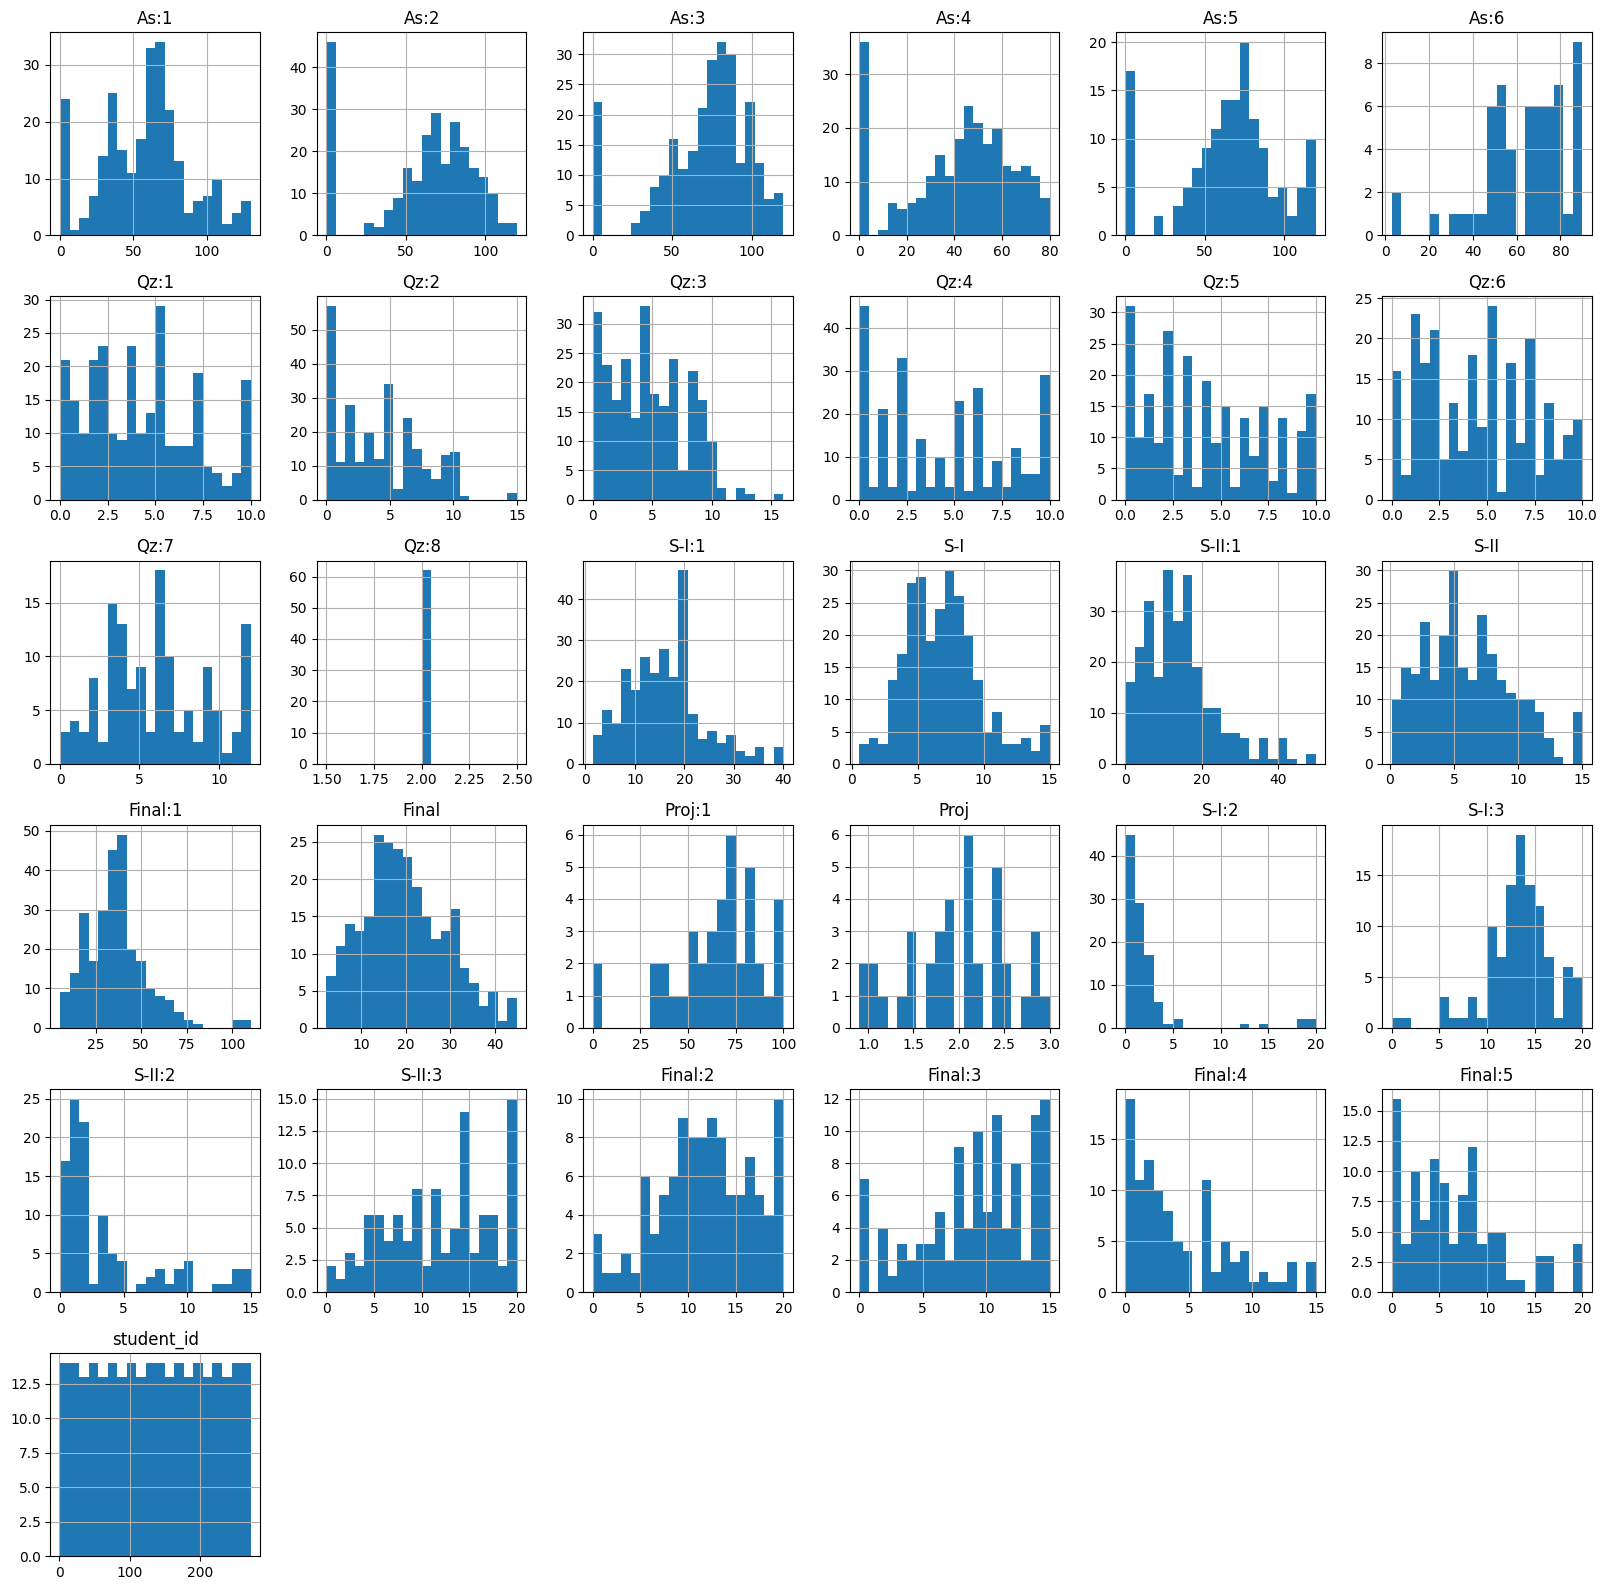

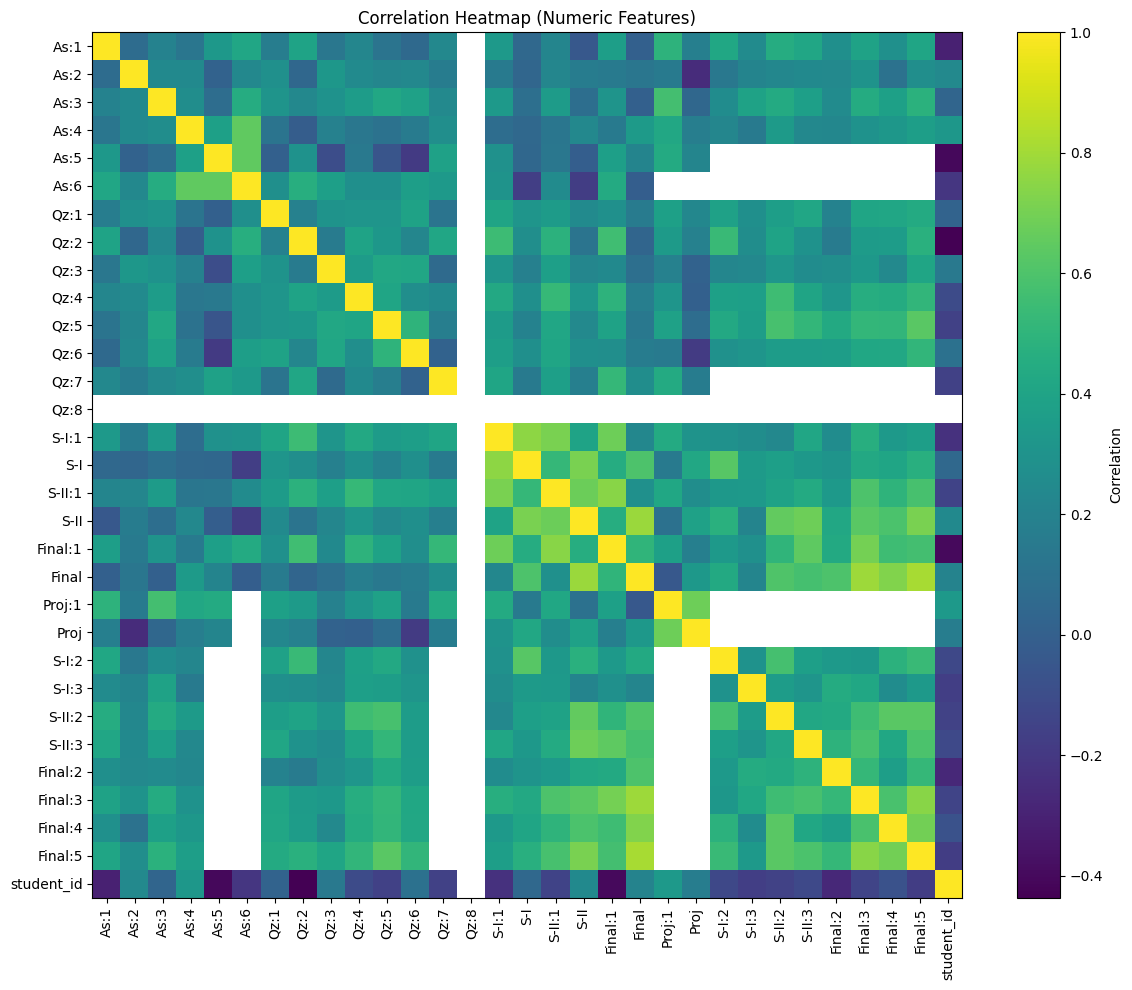

In [8]:
# ### 3.1 Histograms of Numeric Variables

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)

df[numeric_cols].hist(bins=20, figsize=(16, 16))
plt.tight_layout()
plt.show()

# ### 3.2 Correlation Heatmap (Numeric Features Only)
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


Cell 6 – Automatic Column Detection (Midterm I, II, Final)

In [9]:
# ## 4. Detect Target Columns (Midterm I, Midterm II, Final Exam)
#
# We use simple name patterns. Adjust the fallback manual settings if needed.

all_cols_lower = {c: c.lower() for c in df.columns}

def find_cols_by_keywords(keywords, exclude_keywords=None):
    cols = []
    for c, cl in all_cols_lower.items():
        if all(k in cl for k in keywords):
            if exclude_keywords and any(ex in cl for ex in exclude_keywords):
                continue
            cols.append(c)
    return cols

# Heuristics (feel free to adjust manually if needed)
mid1_candidates = (
    find_cols_by_keywords(["mid", "1"]) +
    find_cols_by_keywords(["midterm", "1"]) +
    find_cols_by_keywords(["mid", "i"])
)
mid2_candidates = (
    find_cols_by_keywords(["mid", "2"]) +
    find_cols_by_keywords(["midterm", "2"]) +
    find_cols_by_keywords(["mid", "ii"])
)
final_candidates = (
    find_cols_by_keywords(["final"]) +
    find_cols_by_keywords(["final", "exam"])
)

print("Midterm I candidates:", mid1_candidates)
print("Midterm II candidates:", mid2_candidates)
print("Final exam candidates:", final_candidates)

# ---- MANUAL FALLBACK (edit here if auto-detect fails) ----
if len(mid1_candidates) == 0:
    # e.g. "Midterm I" or "Mid 1 (40)" etc.
    MID1_COL = "Midterm I"   # <-- change to your exact column name
else:
    MID1_COL = mid1_candidates[0]

if len(mid2_candidates) == 0:
    MID2_COL = "Midterm II"  # <-- change to your exact column name
else:
    MID2_COL = mid2_candidates[0]

if len(final_candidates) == 0:
    FINAL_COL = "Final"      # <-- change to your exact column name
else:
    FINAL_COL = final_candidates[0]

print("Using columns:")
print("  MID1_COL =", MID1_COL)
print("  MID2_COL =", MID2_COL)
print("  FINAL_COL =", FINAL_COL)


Midterm I candidates: []
Midterm II candidates: []
Final exam candidates: ['Final:1', 'Final', 'Final:2', 'Final:3', 'Final:4', 'Final:5']
Using columns:
  MID1_COL = Midterm I
  MID2_COL = Midterm II
  FINAL_COL = Final:1


Cell 7 – Define Feature Groups & Domain Logic (No Data Leakage)

In [14]:

print("===== COLUMN NAMES IN YOUR DATASET =====\n")
for col in df.columns:
    print(col)

# ## 5. Feature Selection with Domain Knowledge (No Leakage)

# === 1) Drop junk ID column if exists ===
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# === 2) Identify true column groups ===
# Assignments
assign_cols = [c for c in df.columns if c.lower().startswith("as:")]

# Quizzes
quiz_cols = [c for c in df.columns if c.lower().startswith("qz:")]

# Projects
project_cols = [c for c in df.columns if c.lower().startswith("proj")]

# Midterm I (Sessional I)
mid1_cols = [c for c in df.columns if c.lower().startswith("s-i")]

# Midterm II (Sessional II)
mid2_cols = [c for c in df.columns if c.lower().startswith("s-ii")]

# Final Exam variations
final_cols = [c for c in df.columns if c.lower().startswith("final")]

print("Assignments:", assign_cols)
print("Quizzes:", quiz_cols)
print("Projects:", project_cols)
print("Midterm I columns:", mid1_cols)
print("Midterm II columns:", mid2_cols)
print("Final Exam columns:", final_cols)

# === 3) Choose the main target columns ===
MID1_COL = mid1_cols[0]     # first occurrence
MID2_COL = mid2_cols[0]     # first occurrence
FINAL_COL = final_cols[0]   # first occurrence

print("\nSelected Target Columns:")
print("MID1 =", MID1_COL)
print("MID2 =", MID2_COL)
print("FINAL =", FINAL_COL)

# === 4) Define assessment feature set (NO leakage) ===
assessment_cols = assign_cols + quiz_cols + project_cols  # only formative assessment

# === 5) Domain-safe features per RQ ===
# RQ1: Predict Midterm I → Only assignments, quizzes, projects (NO exams)
features_rq1 = assessment_cols.copy()

# RQ2: Predict Midterm II → Can use Midterm I + assessments
features_rq2 = [MID1_COL] + assessment_cols.copy()

# RQ3: Predict Final → Can use both midterms + assessments
features_rq3 = [MID1_COL, MID2_COL] + assessment_cols.copy()

print("\nFinal Feature Selection:")
print("RQ1 Features:", features_rq1)
print("RQ2 Features:", features_rq2)
print("RQ3 Features:", features_rq3)

# === 6) Make modeling dataset without missing exam targets ===
df_model = df.dropna(subset=[MID1_COL, MID2_COL, FINAL_COL])
df_model.shape


===== COLUMN NAMES IN YOUR DATASET =====

As:1
As:2
As:3
As:4
As:5
As:6
Qz:1
Qz:2
Qz:3
Qz:4
Qz:5
Qz:6
Qz:7
Qz:8
S-I:1
S-I
S-II:1
S-II
Final:1
Final
sheet_source
Proj:1
Proj
S-I:2
S-I:3
S-II:2
S-II:3
Final:2
Final:3
Final:4
Final:5
student_id
Assignments: ['As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6']
Quizzes: ['Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8']
Projects: ['Proj:1', 'Proj']
Midterm I columns: ['S-I:1', 'S-I', 'S-II:1', 'S-II', 'S-I:2', 'S-I:3', 'S-II:2', 'S-II:3']
Midterm II columns: ['S-II:1', 'S-II', 'S-II:2', 'S-II:3']
Final Exam columns: ['Final:1', 'Final', 'Final:2', 'Final:3', 'Final:4', 'Final:5']

Selected Target Columns:
MID1 = S-I:1
MID2 = S-II:1
FINAL = Final:1

Final Feature Selection:
RQ1 Features: ['As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'Proj:1', 'Proj']
RQ2 Features: ['S-I:1', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6

(264, 32)

Cell 8 – Workflow Diagram (Simple Visual)

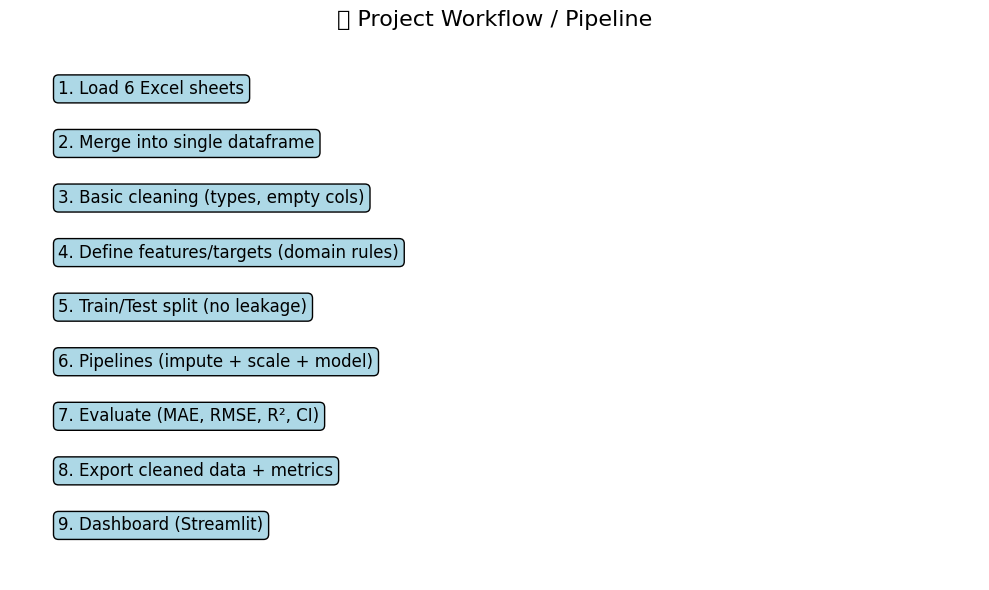

In [16]:
# ## 6. Workflow / Pipeline Diagram (Fixed & Visible Version)

steps = [
    "Load 6 Excel sheets",
    "Merge into single dataframe",
    "Basic cleaning (types, empty cols)",
    "Define features/targets (domain rules)",
    "Train/Test split (no leakage)",
    "Pipelines (impute + scale + model)",
    "Evaluate (MAE, RMSE, R², CI)",
    "Export cleaned data + metrics",
    "Dashboard (Streamlit)"
]

plt.figure(figsize=(10, 6))

# Fix: Proper y coordinates
y_positions = list(range(len(steps)))[::-1]

# Draw boxes + text
for i, (y, step) in enumerate(zip(y_positions, steps)):
    plt.text(
        0.05, y, f"{i+1}. {step}",
        fontsize=12, va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black")
    )

# Fix: Set visible axis range
plt.ylim(-1, len(steps))

# Remove axes
plt.yticks([])
plt.xticks([])
plt.box(False)

plt.title("📌 Project Workflow / Pipeline", fontsize=16)
plt.tight_layout()
plt.show()


Cell 9 – Helper Functions (Metrics, Bootstrapping, Model Training)

In [15]:

# ## 7. Helper Functions (Metrics, Bootstrapping, Model Training)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def bootstrap_mae_ci(model, X_train, y_train, n_bootstrap=500, alpha=0.05):
    """
    Bootstrapping MAE CI using only training data.
    For each bootstrap sample:
      - resample train (with replacement)
      - fit model on bootstrap sample
      - evaluate MAE on out-of-bag instances (if any),
        otherwise on the bootstrap sample itself.
    """
    maes = []

    n = len(X_train)
    indices = np.arange(n)

    for _ in range(n_bootstrap):
        boot_idx = resample(indices, replace=True, n_samples=n)
        oob_idx = np.setdiff1d(indices, boot_idx)

        X_boot = X_train.iloc[boot_idx]
        y_boot = y_train.iloc[boot_idx]

        model_clone = sklearn.base.clone(model)
        model_clone.fit(X_boot, y_boot)

        if len(oob_idx) > 0:
            X_eval = X_train.iloc[oob_idx]
            y_eval = y_train.iloc[oob_idx]
        else:
            X_eval = X_boot
            y_eval = y_boot

        y_pred = model_clone.predict(X_eval)
        mae = mean_absolute_error(y_eval, y_pred)
        maes.append(mae)

    lower = np.percentile(maes, 100 * alpha / 2)
    upper = np.percentile(maes, 100 * (1 - alpha / 2))
    return lower, upper, maes


import sklearn.base  # used for model cloning


def train_and_evaluate_rq(
    df,
    feature_cols,
    target_col,
    rq_name,
    random_state=RANDOM_STATE,
    test_size=0.2
):
    """
    Train:
      - DummyRegressor
      - Simple Linear Regression (best single feature)
      - Multiple/Polynomial Regression
    Return a list of dicts with metrics, and best_model info.
    """
    df_use = df.dropna(subset=feature_cols + [target_col]).copy()
    X = df_use[feature_cols]
    y = df_use[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    numeric_features = feature_cols  # all selected features are numeric

    numeric_transform = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # =====================
    # 1) Dummy Regressor
    # =====================
    dummy_model = DummyRegressor(strategy="mean")

    dummy_pipe = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("num", numeric_transform, numeric_features)],
            remainder="drop"
        )),
        ("model", dummy_model)
    ])

    dummy_pipe.fit(X_train, y_train)
    y_train_pred_dummy = dummy_pipe.predict(X_train)
    y_test_pred_dummy = dummy_pipe.predict(X_test)
    mae_tr_d, rmse_tr_d, r2_tr_d = compute_metrics(y_train, y_train_pred_dummy)
    mae_te_d, rmse_te_d, r2_te_d = compute_metrics(y_test, y_test_pred_dummy)

    results = []
    results.append({
        "RQ": rq_name,
        "Model": "DummyRegressor(mean)",
        "Features": "n/a",
        "Train_MAE": mae_tr_d,
        "Train_RMSE": rmse_tr_d,
        "Train_R2": r2_tr_d,
        "Test_MAE": mae_te_d,
        "Test_RMSE": rmse_te_d,
        "Test_R2": r2_te_d,
        "Bootstrap_MAE_CI_Lower": np.nan,
        "Bootstrap_MAE_CI_Upper": np.nan
    })

    # =====================
    # 2) Simple Linear Regression
    # =====================
    # pick best single feature by correlation magnitude with target
    corrs = {}
    for feat in feature_cols:
        if df_use[feat].nunique() > 1:
            corrs[feat] = abs(df_use[[feat, target_col]].corr().iloc[0, 1])
        else:
            corrs[feat] = 0.0

    simple_feature = max(corrs, key=corrs.get)
    print(f"[{rq_name}] Simple Linear Regression feature:", simple_feature)

    simple_numeric_transform = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    simple_pipe = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("num", simple_numeric_transform, [simple_feature])],
            remainder="drop"
        )),
        ("model", LinearRegression())
    ])

    simple_pipe.fit(X_train[[simple_feature]], y_train)
    y_train_pred_s = simple_pipe.predict(X_train[[simple_feature]])
    y_test_pred_s = simple_pipe.predict(X_test[[simple_feature]])

    mae_tr_s, rmse_tr_s, r2_tr_s = compute_metrics(y_train, y_train_pred_s)
    mae_te_s, rmse_te_s, r2_te_s = compute_metrics(y_test, y_test_pred_s)

    results.append({
        "RQ": rq_name,
        "Model": "Simple Linear Regression",
        "Features": simple_feature,
        "Train_MAE": mae_tr_s,
        "Train_RMSE": rmse_tr_s,
        "Train_R2": r2_tr_s,
        "Test_MAE": mae_te_s,
        "Test_RMSE": rmse_te_s,
        "Test_R2": r2_te_s,
        "Bootstrap_MAE_CI_Lower": np.nan,
        "Bootstrap_MAE_CI_Upper": np.nan
    })

    # =====================
    # 3) Multiple / Polynomial Regression
    # =====================
    # We'll use degree-2 polynomial regression on all numeric features.
    poly_pipeline = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("poly", PolynomialFeatures(degree=2, include_bias=False))
                ]), numeric_features)
            ],
            remainder="drop"
        )),
        ("model", LinearRegression())
    ])

    poly_pipeline.fit(X_train, y_train)
    y_train_pred_p = poly_pipeline.predict(X_train)
    y_test_pred_p = poly_pipeline.predict(X_test)

    mae_tr_p, rmse_tr_p, r2_tr_p = compute_metrics(y_train, y_train_pred_p)
    mae_te_p, rmse_te_p, r2_te_p = compute_metrics(y_test, y_test_pred_p)

    # Bootstrapping 95% CI for Test MAE of this (best) model
    print(f"[{rq_name}] Bootstrapping MAE CI for Polynomial Regression...")
    # Best model = polynomial model
    ci_lower, ci_upper, mae_samples = bootstrap_mae_ci(
        poly_pipeline, X_train, y_train, n_bootstrap=500
    )

    results.append({
        "RQ": rq_name,
        "Model": "Polynomial Regression (deg=2)",
        "Features": f"{len(numeric_features)} features",
        "Train_MAE": mae_tr_p,
        "Train_RMSE": rmse_tr_p,
        "Train_R2": r2_tr_p,
        "Test_MAE": mae_te_p,
        "Test_RMSE": rmse_te_p,
        "Test_R2": r2_te_p,
        "Bootstrap_MAE_CI_Lower": ci_lower,
        "Bootstrap_MAE_CI_Upper": ci_upper
    })

    # For overfitting/underfitting discussion, we return also the poly_pipeline
    best_model_info = {
        "best_model_name": "Polynomial Regression (deg=2)",
        "best_pipeline": poly_pipeline,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    return results, best_model_info


Cell 10 – Train Models for RQ1, RQ2, RQ3

In [ ]:
# ## 7. Helper Functions (Metrics, Bootstrapping, Model Training)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def bootstrap_mae_ci(model, X_train, y_train, n_bootstrap=500, alpha=0.05):
    """
    Bootstrapping MAE CI using only training data.
    For each bootstrap sample:
      - resample train (with replacement)
      - fit model on bootstrap sample
      - evaluate MAE on out-of-bag instances (if any),
        otherwise on the bootstrap sample itself.
    """
    maes = []

    n = len(X_train)
    indices = np.arange(n)

    for _ in range(n_bootstrap):
        boot_idx = resample(indices, replace=True, n_samples=n)
        oob_idx = np.setdiff1d(indices, boot_idx)

        X_boot = X_train.iloc[boot_idx]
        y_boot = y_train.iloc[boot_idx]

        model_clone = sklearn.base.clone(model)
        model_clone.fit(X_boot, y_boot)

        if len(oob_idx) > 0:
            X_eval = X_train.iloc[oob_idx]
            y_eval = y_train.iloc[oob_idx]
        else:
            X_eval = X_boot
            y_eval = y_boot

        y_pred = model_clone.predict(X_eval)
        mae = mean_absolute_error(y_eval, y_pred)
        maes.append(mae)

    lower = np.percentile(maes, 100 * alpha / 2)
    upper = np.percentile(maes, 100 * (1 - alpha / 2))
    return lower, upper, maes


import sklearn.base  # used for model cloning


def train_and_evaluate_rq(
    df,
    feature_cols,
    target_col,
    rq_name,
    random_state=RANDOM_STATE,
    test_size=0.2
):
    """
    Train:
      - DummyRegressor
      - Simple Linear Regression (best single feature)
      - Multiple/Polynomial Regression
    Return a list of dicts with metrics, and best_model info.
    """
    df_use = df.dropna(subset=feature_cols + [target_col]).copy()
    X = df_use[feature_cols]
    y = df_use[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    numeric_features = feature_cols  # all selected features are numeric

    numeric_transform = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # =====================
    # 1) Dummy Regressor
    # =====================
    dummy_model = DummyRegressor(strategy="mean")

    dummy_pipe = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("num", numeric_transform, numeric_features)],
            remainder="drop"
        )),
        ("model", dummy_model)
    ])

    dummy_pipe.fit(X_train, y_train)
    y_train_pred_dummy = dummy_pipe.predict(X_train)
    y_test_pred_dummy = dummy_pipe.predict(X_test)
    mae_tr_d, rmse_tr_d, r2_tr_d = compute_metrics(y_train, y_train_pred_dummy)
    mae_te_d, rmse_te_d, r2_te_d = compute_metrics(y_test, y_test_pred_dummy)

    results = []
    results.append({
        "RQ": rq_name,
        "Model": "DummyRegressor(mean)",
        "Features": "n/a",
        "Train_MAE": mae_tr_d,
        "Train_RMSE": rmse_tr_d,
        "Train_R2": r2_tr_d,
        "Test_MAE": mae_te_d,
        "Test_RMSE": rmse_te_d,
        "Test_R2": r2_te_d,
        "Bootstrap_MAE_CI_Lower": np.nan,
        "Bootstrap_MAE_CI_Upper": np.nan
    })

    # =====================
    # 2) Simple Linear Regression
    # =====================
    # pick best single feature by correlation magnitude with target
    corrs = {}
    for feat in feature_cols:
        if df_use[feat].nunique() > 1:
            corrs[feat] = abs(df_use[[feat, target_col]].corr().iloc[0, 1])
        else:
            corrs[feat] = 0.0

    simple_feature = max(corrs, key=corrs.get)
    print(f"[{rq_name}] Simple Linear Regression feature:", simple_feature)

    simple_numeric_transform = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    simple_pipe = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("num", simple_numeric_transform, [simple_feature])],
            remainder="drop"
        )),
        ("model", LinearRegression())
    ])

    simple_pipe.fit(X_train[[simple_feature]], y_train)
    y_train_pred_s = simple_pipe.predict(X_train[[simple_feature]])
    y_test_pred_s = simple_pipe.predict(X_test[[simple_feature]])

    mae_tr_s, rmse_tr_s, r2_tr_s = compute_metrics(y_train, y_train_pred_s)
    mae_te_s, rmse_te_s, r2_te_s = compute_metrics(y_test, y_test_pred_s)

    results.append({
        "RQ": rq_name,
        "Model": "Simple Linear Regression",
        "Features": simple_feature,
        "Train_MAE": mae_tr_s,
        "Train_RMSE": rmse_tr_s,
        "Train_R2": r2_tr_s,
        "Test_MAE": mae_te_s,
        "Test_RMSE": rmse_te_s,
        "Test_R2": r2_te_s,
        "Bootstrap_MAE_CI_Lower": np.nan,
        "Bootstrap_MAE_CI_Upper": np.nan
    })

    # =====================
    # 3) Multiple / Polynomial Regression
    # =====================
    # We'll use degree-2 polynomial regression on all numeric features.
    poly_pipeline = Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("poly", PolynomialFeatures(degree=2, include_bias=False))
                ]), numeric_features)
            ],
            remainder="drop"
        )),
        ("model", LinearRegression())
    ])

    poly_pipeline.fit(X_train, y_train)
    y_train_pred_p = poly_pipeline.predict(X_train)
    y_test_pred_p = poly_pipeline.predict(X_test)

    mae_tr_p, rmse_tr_p, r2_tr_p = compute_metrics(y_train, y_train_pred_p)
    mae_te_p, rmse_te_p, r2_te_p = compute_metrics(y_test, y_test_pred_p)

    # Bootstrapping 95% CI for Test MAE of this (best) model
    print(f"[{rq_name}] Bootstrapping MAE CI for Polynomial Regression...")
    # Best model = polynomial model
    ci_lower, ci_upper, mae_samples = bootstrap_mae_ci(
        poly_pipeline, X_train, y_train, n_bootstrap=500
    )

    results.append({
        "RQ": rq_name,
        "Model": "Polynomial Regression (deg=2)",
        "Features": f"{len(numeric_features)} features",
        "Train_MAE": mae_tr_p,
        "Train_RMSE": rmse_tr_p,
        "Train_R2": r2_tr_p,
        "Test_MAE": mae_te_p,
        "Test_RMSE": rmse_te_p,
        "Test_R2": r2_te_p,
        "Bootstrap_MAE_CI_Lower": ci_lower,
        "Bootstrap_MAE_CI_Upper": ci_upper
    })

    # For overfitting/underfitting discussion, we return also the poly_pipeline
    best_model_info = {
        "best_model_name": "Polynomial Regression (deg=2)",
        "best_pipeline": poly_pipeline,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    return results, best_model_info


In [17]:
# === SAFE IMPUTATION OF FORMATIVE ASSESSMENTS (no leakage) ===

# impute missing formative marks with 0 (safe domain rule: no credit = 0)
for col in assessment_cols:
    df[col] = df[col].fillna(0)

# IMPORTANT: DO NOT FILL EXAM SCORES (midterms/final)
# Re-create df_model after fixing assessment columns
df_model = df.dropna(subset=[MID1_COL, MID2_COL, FINAL_COL])

print("Rows after safe imputation:", df_model.shape)


Rows after safe imputation: (264, 32)


In [18]:
# ## 8. Model Training & Evaluation for Each Research Question

all_results = []
best_models = {}

# RQ1: Predict Midterm I
rq1_results, rq1_best = train_and_evaluate_rq(
    df_model,
    features_rq1,
    MID1_COL,
    rq_name="RQ1: Predict Midterm I"
)
all_results.extend(rq1_results)
best_models["RQ1"] = rq1_best

# RQ2: Predict Midterm II
rq2_results, rq2_best = train_and_evaluate_rq(
    df_model,
    features_rq2,
    MID2_COL,
    rq_name="RQ2: Predict Midterm II"
)
all_results.extend(rq2_results)
best_models["RQ2"] = rq2_best

# RQ3: Predict Final Exam
rq3_results, rq3_best = train_and_evaluate_rq(
    df_model,
    features_rq3,
    FINAL_COL,
    rq_name="RQ3: Predict Final Exam"
)
all_results.extend(rq3_results)
best_models["RQ3"] = rq3_best

results_df = pd.DataFrame(all_results)
results_df


[RQ1: Predict Midterm I] Simple Linear Regression feature: Qz:2
[RQ1: Predict Midterm I] Bootstrapping MAE CI for Polynomial Regression...
[RQ2: Predict Midterm II] Simple Linear Regression feature: S-I:1
[RQ2: Predict Midterm II] Bootstrapping MAE CI for Polynomial Regression...
[RQ3: Predict Final Exam] Simple Linear Regression feature: S-II:1
[RQ3: Predict Final Exam] Bootstrapping MAE CI for Polynomial Regression...


,RQ,Model,Features,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Bootstrap_MAE_CI_Lower,Bootstrap_MAE_CI_Upper
0,RQ1: Predict Midterm I,DummyRegressor(mean),n/a,5.719840,7.447882,0.000000,6.777251,8.175287,-0.011990,NaN,NaN
1,RQ1: Predict Midterm I,Simple Linear Regression,Qz:2,4.980440,6.139869,0.320401,6.043980,7.281158,0.197267,NaN,NaN
2,RQ1: Predict Midterm I,Polynomial Regression (deg=2),16 features,2.259612,3.027024,0.834817,8.560807,11.272285,-0.923952,25.470573,2025.809526
3,RQ2: Predict Midterm II,DummyRegressor(mean),n/a,6.954298,9.259058,0.000000,8.120827,10.711565,-0.000148,NaN,NaN
4,RQ2: Predict Midterm II,Simple Linear Regression,S-I:1,5.292076,6.611795,0.490076,5.784577,7.190990,0.549250,NaN,NaN
5,RQ2: Predict Midterm II,Polynomial Regression (deg=2),17 features,1.569642,2.112117,0.947964,12.803366,18.202079,-1.888020,11.039438,34.026252
6,RQ3: Predict Final Exam,DummyRegressor(mean),n/a,11.541588,16.073559,0.000000,13.968470,18.961164,-0.000244,NaN,NaN
7,RQ3: Predict Final Exam,Simple Linear Regression,S-II:1,8.464894,10.919917,0.538454,9.322808,11.803952,0.612358,NaN,NaN
8,RQ3: Predict Final Exam,Polynomial Regression (deg=2),18 features,1.927080,2.782249,0.970038,19.154367,30.739990,-1.628956,13.731416,32.903441


Cell 11 – Model Comparison Tables (Per RQ)

In [ ]:
# ## 9. Model Comparison Tables (Per RQ)
#
# We compare:
# - DummyRegressor
# - Simple Linear Regression
# - Polynomial Regression
#
# Metrics: MAE, RMSE, R², and 95% CI for MAE (for best model).

def display_rq_results(rq_label):
    df_rq = results_df[results_df["RQ"] == rq_label].copy()
    display(df_rq[[
        "RQ", "Model", "Features",
        "Train_MAE", "Train_RMSE", "Train_R2",
        "Test_MAE", "Test_RMSE", "Test_R2",
        "Bootstrap_MAE_CI_Lower", "Bootstrap_MAE_CI_Upper"
    ]])

print("Results for RQ1:")
display_rq_results("RQ1: Predict Midterm I")

print("\nResults for RQ2:")
display_rq_results("RQ2: Predict Midterm II")

print("\nResults for RQ3:")
display_rq_results("RQ3: Predict Final Exam")


Results for RQ1:


,RQ,Model,Features,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Bootstrap_MAE_CI_Lower,Bootstrap_MAE_CI_Upper
0,RQ1: Predict Midterm I,DummyRegressor(mean),n/a,5.719840,7.447882,0.000000,6.777251,8.175287,-0.011990,NaN,NaN
1,RQ1: Predict Midterm I,Simple Linear Regression,Qz:2,4.980440,6.139869,0.320401,6.043980,7.281158,0.197267,NaN,NaN
2,RQ1: Predict Midterm I,Polynomial Regression (deg=2),16 features,2.259612,3.027024,0.834817,8.560807,11.272285,-0.923952,25.470573,2025.809526



Results for RQ2:


,RQ,Model,Features,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Bootstrap_MAE_CI_Lower,Bootstrap_MAE_CI_Upper
3,RQ2: Predict Midterm II,DummyRegressor(mean),n/a,6.954298,9.259058,0.000000,8.120827,10.711565,-0.000148,NaN,NaN
4,RQ2: Predict Midterm II,Simple Linear Regression,S-I:1,5.292076,6.611795,0.490076,5.784577,7.190990,0.549250,NaN,NaN
5,RQ2: Predict Midterm II,Polynomial Regression (deg=2),17 features,1.569642,2.112117,0.947964,12.803366,18.202079,-1.888020,11.039438,34.026252



Results for RQ3:


,RQ,Model,Features,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Bootstrap_MAE_CI_Lower,Bootstrap_MAE_CI_Upper
6,RQ3: Predict Final Exam,DummyRegressor(mean),n/a,11.541588,16.073559,0.000000,13.968470,18.961164,-0.000244,NaN,NaN
7,RQ3: Predict Final Exam,Simple Linear Regression,S-II:1,8.464894,10.919917,0.538454,9.322808,11.803952,0.612358,NaN,NaN
8,RQ3: Predict Final Exam,Polynomial Regression (deg=2),18 features,1.927080,2.782249,0.970038,19.154367,30.739990,-1.628956,13.731416,32.903441


Cell 12 – Train vs Test Performance of Best Models (Over/Underfitting)

RQ1 - Polynomial Regression (deg=2)
Train MAE, RMSE, R²: 2.2596124924559144 3.0270236108805686 0.8348167280962302
Test  MAE, RMSE, R²: 8.560807035988981 11.272284705873961 -0.9239521474977717


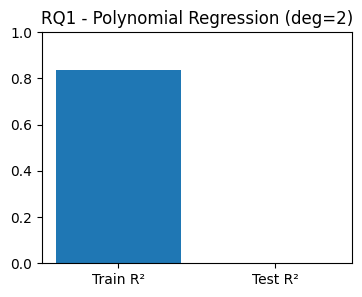

RQ2 - Polynomial Regression (deg=2)
Train MAE, RMSE, R²: 1.5696415237371066 2.112116997694757 0.9479641840905182
Test  MAE, RMSE, R²: 12.803365973694492 18.20207929080488 -1.8880199211175341


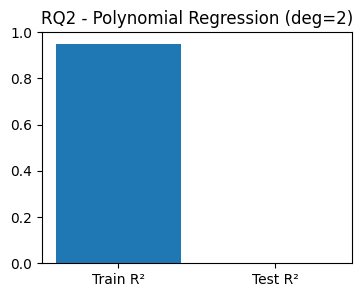

RQ3 - Polynomial Regression (deg=2)
Train MAE, RMSE, R²: 1.9270796892830457 2.782249298944947 0.9700381941608003
Test  MAE, RMSE, R²: 19.154366673631205 30.73998979059462 -1.6289557322175923


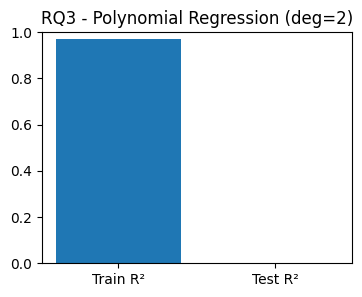

In [20]:

# ## 10. Train vs Test Performance of Best Models (Over/Underfitting)

for rq_key, bm in best_models.items():
    print("=" * 60)
    print(rq_key, "-", bm["best_model_name"])
    X_train = bm["X_train"]
    X_test = bm["X_test"]
    y_train = bm["y_train"]
    y_test = bm["y_test"]
    pipe = bm["best_pipeline"]

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    mae_tr, rmse_tr, r2_tr = compute_metrics(y_train, y_train_pred)
    mae_te, rmse_te, r2_te = compute_metrics(y_test, y_test_pred)

    print("Train MAE, RMSE, R²:", mae_tr, rmse_tr, r2_tr)
    print("Test  MAE, RMSE, R²:", mae_te, rmse_te, r2_te)

    # Quick bar plot for R² comparison
    plt.figure(figsize=(4, 3))
    plt.bar(["Train R²", "Test R²"], [r2_tr, r2_te])
    plt.title(f"{rq_key} - {bm['best_model_name']}")
    plt.ylim(0, 1)
    plt.show()


Cell 13 – Export Cleaned Preprocessed Dataset (CSV) & Results for Dashboard

In [21]:
# ## 11. Export Cleaned Preprocessed Dataset and Model Results
#
# To avoid data leakage:
# - The *cleaned dataset* contains original features with label-independent cleaning.
# - The * Pipelines* inside the models handle imputation and scaling **after** train/test split.
#
# These files will be used by the Streamlit dashboard.

# %%
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# 1) Cleaned dataset (basic cleaning, no imputation based on full data distribution)
cleaned_path = os.path.join(output_dir, "cleaned_marks_dataset.csv")
df_model.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to:", cleaned_path)

# 2) Model results (for dashboard)
results_path = os.path.join(output_dir, "model_results.csv")
results_df.to_csv(results_path, index=False)
print("Saved model results to:", results_path)


Saved cleaned dataset to: outputs/cleaned_marks_dataset.csv
Saved model results to: outputs/model_results.csv


In [22]:
output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)

df_model.to_csv(os.path.join(output_dir, "cleaned_marks_dataset.csv"), index=False)
results_df.to_csv(os.path.join(output_dir, "model_results.csv"), index=False)

print("Saved in:", output_dir)


Saved in: /content/outputs


In [25]:
import os

output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)

df_model.to_csv(os.path.join(output_dir, "cleaned_marks_dataset.csv"), index=False)
results_df.to_csv(os.path.join(output_dir, "model_results.csv"), index=False)

print("Saved to:", output_dir)


Saved to: /content/outputs


In [26]:
from google.colab import files
files.download("outputs/model_results.csv")
files.download("outputs/cleaned_marks_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
print("df_model exists:", "df_model" in globals())
print("results_df exists:", "results_df" in globals())


df_model exists: True
results_df exists: True


In [28]:
import os

output_dir = "/content/outputs"
os.makedirs(output_dir, exist_ok=True)

cleaned_path = os.path.join(output_dir, "cleaned_marks_dataset.csv")
results_path = os.path.join(output_dir, "model_results.csv")

df_model.to_csv(cleaned_path, index=False)
results_df.to_csv(results_path, index=False)

print("Files created successfully at:", output_dir)


Files created successfully at: /content/outputs


Cell 14 – Final Conclusions in Notebook

In [ ]:
# ## 12. Final Conclusions (Summary)
#
# ### RQ1: Predict Midterm I
# - Compare the MAE/RMSE of Simple Regression vs Dummy.
# - If the polynomial model significantly improves Test MAE and R², it suggests that
#   early assessments (quizzes/assignments) contain useful predictive information.
# - Watch for overfitting: if Train R² is much higher than Test R², complexity may be too high.
#
# ### RQ2: Predict Midterm II
# - Adding Midterm I as a feature should improve prediction accuracy over using only quizzes/assignments.
# - A much lower MAE than Dummy indicates that Midterm I is a strong predictor.
#
# ### RQ3: Predict Final Exam
# - When using Midterm I, Midterm II, and continuous assessments, we expect the highest R² among all RQs,
#   because Final marks are often cumulative.
# - Check whether polynomial regression provides clear benefit; if the gap between Train and Test
#   performance is small, the model generalizes well.
#
# Across all RQs:
# - DummyRegressor provides a baseline (mean predictor).
# - Linear models show how much signal is present in the data beyond a simple average.
# - The 95% confidence intervals of MAE (from bootstrapping) help us understand the stability of
#   our model performance on different possible samples of students.
